# Finetuning for Text Classification

## Different categories of finetuning

- LM을 fine-tuuning 하는 가장 일반적인 방법은 instruction-finetuning과 classification finetuning.
- instruction finetuning은 다음 chapter에서 할 내용.

![inst_tuning](https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/02.webp)

- 이번에는 classification finetuning. ML에 대한 배경지식이 있으면 익숙한 내용.
  - digit을 분류하도록 CNN을 train하는 것과 유사한 작업임.
- classification finetuning에서 label의 개수는 정해져 있음. (e.g. "spam", "not spam")
  - finetuning하는 중에는 training 중에 학습한 class만 예측할 수 있지만, instruction finetuning은 일반적으로 더 많은 작업을 수행할 수 있음.
- classification에 매우 특화된 모델로도 생각할 수 있음.
  - 다양한 task에서 뛰어난 성능을 보이는 generalized model을 만드는 것 보다, specialized model을 만드는게 더 쉽기도 함.

![class_tuning](https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/03.webp)


## Preparing dataset

![dataset](https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/04.webp)

- classification finetuning을 위한 dataset을 준비할 것.
  - spam 및 non-spam text message로 구성된 dataset을 사용해 LLM을 finetune 해볼 것.

In [1]:
import requests
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return

    # Downloading the file
    response = requests.get(url, stream=True, timeout=60)
    response.raise_for_status()
    with open(zip_path, "wb") as out_file:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                out_file.write(chunk)

    # Unzipping the file
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    # Add .tsv file extension
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")


try:
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)
except (requests.exceptions.RequestException, TimeoutError) as e:
    print(f"Primary URL failed: {e}. Trying backup URL...")
    url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/sms%2Bspam%2Bcollection.zip"
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)


sms_spam_collection\SMSSpamCollection.tsv already exists. Skipping download and extraction.


- tsv는 tab-separated text file. pandas로 read 가능.

In [2]:
import pandas as pd

df = pd.read_csv(data_file_path, sep='\t', header=None, names=['Label', 'Text'])
print(df)
print(df["Label"].value_counts())

     Label                                               Text
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...
...    ...                                                ...
5567  spam  This is the 2nd time we have tried 2 contact u...
5568   ham               Will ü b going to esplanade fr home?
5569   ham  Pity, * was in mood for that. So...any other s...
5570   ham  The guy did some bitching but I acted like i'd...
5571   ham                         Rofl. Its true to its name

[5572 rows x 2 columns]
Label
ham     4825
spam     747
Name: count, dtype: int64


- 현재 class 분포를 보면, "ham" ("not spam")이 "spam"보다 훨씬 더 많음.
- 단순화를 위해 + educational purpose (LLM finetuning이 더 빠르기 때문) 때문에, 각 class에서 747개의 instance만 포함하도록 under-sampling 함.
  - undersampling 외에도 class-imbalance를 다루는 방법은 여러가지가 있음. 자세한 내용은 [imblananced-learn user guide](https://imbalanced-learn.org/stable/user_guide.html) 를 참고.

In [3]:
def create_balanced_dataset(df):
    
    # Count the instances of "spam"
    num_spam = df[df["Label"] == "spam"].shape[0]
    
    # Randomly sample "ham" instances to match the number of "spam" instances
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)
    
    # Combine ham "subset" with "spam"
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])

    return balanced_df


balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


- 이어서, class label "ham"과 "spam"을 정수 0, 1로 변환.

In [4]:
balanced_df["Label"] = balanced_df["Label"].map({"ham" : 0, "spam": 1})
balanced_df

,Label,Text
4307,0,Awww dat is sweet! We can think of something t...
4138,0,Just got to &lt;#&gt;
4831,0,"The word ""Checkmate"" in chess comes from the P..."
4461,0,This is wishing you a great day. Moji told me ...
5440,0,Thank you. do you generally date the brothas?
...,...,...
5537,1,Want explicit SEX in 30 secs? Ring 02073162414...
5540,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547,1,Had your contract mobile 11 Mnths? Latest Moto...
5566,1,REMINDER FROM O2: To get 2.50 pounds free call...


- dataset을 training, validation, test subset으로 나누는 함수를 작성.

In [5]:
def random_split(df, train_frac, validation_frac):
    # Shuffle the entire DataFrame
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)

    # Calculate split indices
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    # Split the DataFrame
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)
# Test size is implied to be 0.2 as the remainder

train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

## Creating data loader

- 현재 text message들의 길이가 서로 다름. 여러 training example을 한번에 combine하기 위해선 다음 두 방법 중 하나를 사용해야 함.
    1. dataset 또는 batch에서 가장 짧은 메시지의 길이로 모든 메시지를 자르기.
    2. dataset 또는 batch에서 가장 긴 메시지의 길이로 모든 메시지에 패딩을 추가.
- 여기서는 2번째 padding 방법을 선택.
  - 이전에 사용했던 `<|endoftext|>`를 padding token으로 사용

![padding](https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/06.webp)

In [6]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [7]:
import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)

        # text tokenize
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]

        if max_length is None:
            self.max_length = self._longest_encoded_length()

        else:
            self.max_length = max_length

            # max_length보다 길어지면 이를 제거
            self.encoded_texts = [
                encoded_text[:self.max_length] for encoded_text in self.encoded_texts
            ]
        
        # 가장 긴 시퀀스 길이만큼 padding
        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]
    
    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]

        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def __len__(self):
        return len(self.data)
    
    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length


In [8]:
train_dataset = SpamDataset(
    csv_file = 'train.csv',
    max_length = None,
    tokenizer = tokenizer
)
val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)
test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

print(train_dataset.max_length)
print(val_dataset.max_length)
print(test_dataset.max_length)

120
120
120


- Dataset을 만들었으니 이제 DataLoader를 만들어 보자.

![dataloader](https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/07.webp)

In [9]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

torch.manual_seed(62)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

- dataloader를 iterate하며 각 batch에 8개의 example이 들어있는지 확인.

In [10]:
print("Train loader:")
for input_batch, target_batch in train_loader:
    pass

print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)
print("==========="*8)
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

Train loader:
Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])
130 training batches
19 validation batches
38 test batches


## Initialize a model with pretrained weights

- 이전 chapter에서 사용한 pretrained model을 초기화 해보자

![model_load](https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/08.webp)

In [11]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    'vocab_size': 50257,        # Vocabulary size
    'context_length': 1024,     # Context(max sequence) length
    'drop_rate': 0.0,           # Dropout rate
    'qkv_bias': False,          # Q,K,V bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

assert train_dataset.max_length <= BASE_CONFIG["context_length"], (
    f"Dataset length {train_dataset.max_length} exceeds model's context "
    f"length {BASE_CONFIG['context_length']}. Reinitialize data sets with "
    f"`max_length={BASE_CONFIG['context_length']}`"
)

In [14]:
from _06_download_gpt2 import download_and_load_gpt2
from _05_previous_modules import GPTModel, load_weights_into_gpt

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 5.50kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:01<00:00, 932kiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 90.0kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [09:13<00:00, 899kiB/s]   
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:01<00:00, 4.52kiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:01<00:00, 449kiB/s]  
vocab.bpe: 100%|██████████| 456k/456k [00:01<00:00, 440kiB/s]  


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xf4 in position 25: invalid continuation byte

### *이전에 download했던 model 사용*
### *tf load할때 경로에 영어가 아닌게 섞여있으니 UnicodeDecodeError가 나옴.*

In [13]:
import torch
from _05_previous_modules import GPTModel

file_name = "gpt2-small-124M.pth"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "drop_rate": 0.0,       # Dropout rate
    "qkv_bias": True        # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"embed_dim": 768, "num_layers": 12, "num_heads": 12},
    "gpt2-medium (355M)": {"embed_dim": 1024, "num_layers": 24, "num_heads": 16},
    "gpt2-large (774M)": {"embed_dim": 1280, "num_layers": 36, "num_heads": 20},
    "gpt2-xl (1558M)": {"embed_dim": 1600, "num_layers": 48, "num_heads": 25},
}

CHOOSE_MODEL = "gpt2-small (124M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

# 1. 모델과 체크포인트 준비 (가정)
model = GPTModel(BASE_CONFIG)
checkpoint = torch.load("gpt2-small-124M.pth")

def load_pretrained_gpt2(model, checkpoint):
    new_state_dict = {}
    
    # 변환 규칙 정의 (찾을 단어: 바꿀 단어)
    replacements = {
        "tok_emb": "token_embedding",
        "pos_emb": "position_embedding",
        "trf_blocks": "transformer_blocks",
        ".att.": ".attention.",
        "out_proj": "out_projection",
        ".ff.": ".ffn.",
    }

    for key, value in checkpoint.items():
        new_key = key
        
        # 1. 규칙에 따라 이름 변경
        for old, new in replacements.items():
            new_key = new_key.replace(old, new)
        
        # 2. 내 모델에 해당 Key가 존재하는지 확인
        if new_key in model.state_dict():
            new_state_dict[new_key] = value
        else:
            # 매칭되지 않는 Key 출력 (디버깅용)
            print(f"Skipping: {key} -> {new_key} (Not found in your model)")

    # 3. 로드 (strict=False를 권장: 위에서 제외한 bias 등이 있을 수 있음)
    model.load_state_dict(new_state_dict, strict=False)
    print("\n로드 완료!")

# 실행
load_pretrained_gpt2(model, checkpoint)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_16228\3429531983.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("gpt2-small-124M.pth")



로드 완료!


In [15]:
model.eval()

GPTModel(
  (token_embedding): Embedding(50257, 768)
  (position_embedding): Embedding(1024, 768)
  (drop_embedding): Dropout(p=0.0, inplace=False)
  (transformer_blocks): ModuleList(
    (0-11): 12 x TransformerBlock(
      (attention): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_projection): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
  )
  (final_norm): LayerNo

In [17]:
from _05_previous_modules import (
    generate_text_simple_cached,
    text_to_token_ids,
    token_ids_to_text
)

text_1 = "Every effort moves you"

token_ids = generate_text_simple_cached(
    model = model,
    idx = text_to_token_ids(text_1, tokenizer),
    max_new_tokens = 15,
    context_size = BASE_CONFIG['context_length']
)

print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you make to make a game of it is a game of it.




- finetuning을 하기 전에, 현재 model이 prompting을 통해 spam을 분류할 수 있는지를 확인.

In [18]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)

token_ids = generate_text_simple_cached(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


- 보면 알 수 있듯, 현재 instruction을 잘 따르고 있지 않음.
- 이는 예상된 결과.
  - **model은 현재 pretrain만 거쳤고, instruction-finetune을 하지 않았기 때문**. (다음 chapter에서 할 내용)

## Adding a classification head

![clf_head](https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/09.webp)

- pretrained model을 조금 수정해서 classification finetuning에 쓰도록 해보자.
- 목표는 앞서 구현한 구조에서, **output layer를 교체하고 이를 finetuning** 하는 것.
- 이를 위해선 먼저 **model을 freeze** 한다.
  - 즉, **모든 layer를 non-trainable하게 바꾸는 것**.

In [20]:
model.eval()

GPTModel(
  (token_embedding): Embedding(50257, 768)
  (position_embedding): Embedding(1024, 768)
  (drop_embedding): Dropout(p=0.0, inplace=False)
  (transformer_blocks): ModuleList(
    (0-11): 12 x TransformerBlock(
      (attention): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_projection): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
  )
  (final_norm): LayerNo

In [19]:
for param in model.parameters():
    param.requires_grad = False

- freeze 한 다음, input들을 vocab size인 50257-dim으로 mapping하는 output layer (`model.out_head`)를 교체하는 것.
- 현재 목표는 binary classification (spam/non-spam) 이므로, 이에 맞춰 finetuning 하기 위해 output layer를 교체. (새 instance로 바꿔지는 것 이므로, 기본적으로 trainable 해짐.)
- 코드의 일반성을 위해 `BASE_CONFIG[embed_dim]` (`gpt2-small (124M)`에서의 768)을 사용함.

In [21]:
torch.manual_seed(62)

num_classes = 2
model.out_head = torch.nn.Linear(
    in_features = BASE_CONFIG['embed_dim'],
    out_features = num_classes
)

- 기술적으론 output layer만을 train해도 충분함.
- 하지만, (원 제작자가 작성한 블로그 post)[Finetuning Large Language Models](https://magazine.sebastianraschka.com/p/finetuning-large-language-models)에 기술한 것 처럼, 추가적으로 몇개의 layer를 함께 finetune하면 성능이 눈에 띄게 향상됨을 알 수 있음.
- 따라서, 마지막 transformer block과, 이를 output에 연결하는 마지막 `LayerNorm`도 함께 trainable 하게 함.

![to_finetune](https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/10.webp)

In [22]:
for param in model.transformer_blocks[-1].parameters():
    param.requires_grad = True

for param in model.final_norm.parameters():
    param.requires_grad = True

- 이 model은 이전 chapter에서 한 것 처럼 마찬가지로 계속 사용할 수 있으며, 달라진 점은 output dimension이 50257이 아닌 2라는 것.

In [23]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape) # shape: (batch_size, num_tokens)

with torch.no_grad():
    outputs = model(inputs)

print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape) # shape: (batch_size, num_tokens, num_classes)

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])
Outputs:
 tensor([[[-1.4160,  1.2963],
         [-3.3258,  7.8972],
         [-2.3194,  6.2690],
         [-2.4996,  4.3873]]])
Outputs dimensions: torch.Size([1, 4, 2])


- 각 input token마다 하나의 output vector가 있고, model에 4개의 sample을 입력했으므로 output은 위처럼 4개의 2차원 vector로 구성됨.
- 그림을 보면 아래와 같음.

![output_vector](https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/11.webp)

- chapter 3(Low-level implementation)에서 각 input token을 다른 모든 input token과 연결하는 attention mechanism을 보았고, 마찬가지로 GPT-like model에서 사용되는 casual attention mask를 다뤘음.
  - 이 masking을 통해 현재 token은 현재 및 이전 token에만 attention 연산을 했음.
- 이 attention mechanism에 따르면, **4번째(마지막) token은 앞선 다른 모든 token에 대한 정보를 포함하는 유일한 token**이므로, **모든 token 중에서 가장 많은 정보를 담고 있음**.
  - 따라서, 이 마지막 token에 관심을 가질 수 있고, spam 분류작업을 위해 이를 finetuning할 것.

In [24]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-2.4996,  4.3873]])


![masking](https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/12.webp)

## Calculating classification loss and accuracy

- loss 계산을 보기 전에, 현재 수정된 model output이 어떻게 class label로 바뀌는지 간단히 보자.

![class_label](https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/14.webp)

- 이전 chapter에서 했던 것 처럼, softmax를 통해 output(logit)을 확률 score로 바꾼 후, argmax를 통해 가장 큰 확률값의 index 위치를 구할 수 있음.

In [27]:
print("Last output token:", outputs[:, -1, :])

probas = torch.softmax(outputs[:, -1, :], dim=-1)
label = torch.argmax(probas)
print("Class label:", label.item())

Last output token: tensor([[-2.4996,  4.3873]])
Class label: 1


- 이를 적용해 classification accuracy를 계산할 수 있고, 여기서의 정확도는 주어진 dataset에서 올바르게 예측된 비율을 나타냄.
- 계산을 위해 `argmax` 기반의 prediction code를 dataset의 모든 example에 적용해서 올바른 prediction 비율을 계산할 수 있음.

In [31]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)

    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)

            with torch.no_grad():
                # 마지막 output token의 logit
                logits = model(input_batch)[:, -1, :]
            predicted_labels = torch.argmax(logits, dim=-1)

            # 맞힌 갯수 count
            num_examples += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        
        else:
            break
    
    return correct_predictions / num_examples

In [32]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: cuda


In [33]:
model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes

torch.manual_seed(62)

train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=10)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 57.50%
Validation accuracy: 45.00%
Test accuracy: 48.75%


- 현재 finetune을 하지 않았으므로 prediction 정확도가 썩 좋지 않음.
- finetuning(training)을 시작하기 전, 먼저 training 중에 optimize 할 loss function을 정의해야함.
- 목표는 model의 spam classification accuracy를 최대화 하는 것.
  - 하지만 classification accuracy는 differentiable function이 아님.
- 따라서, classification accuracy를 최대화 하는 대신, cross-entropy loss를 최소화 함.
  - 자세한 내용은 [Introduction to Deep Learning](https://sebastianraschka.com/blog/2021/dl-course.html#l08-multinomial-logistic-regression--softmax-regression) 참고

In [34]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)[:, -1, :]  # Logits of last output token
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

- 이전 chapter에서 사용한 함수와 동일하지만, 모든 token을 최적화 하는 대신 마지막 token만을 최적화 함.

In [35]:
# chapter 5에서 사용한 것과 동일.
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.0

    if len(data_loader) == 0:
        return float('nan')
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # dataloader의 총 batch수와 일치하도록 batch 수를 reduce
        # 즉, num_batches가 dataloader의 batch 수를 초과하는 경우.
        num_batches = min(num_batches, len(data_loader))
    
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            batch_loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += batch_loss.item()
        else:
            break
    
    avg_loss = total_loss / num_batches

    return avg_loss

In [ ]:
# 초기 train/val/test loss를 확인하면 다음과 같음.
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 2.134
Validation loss: 1.970
Test loss: 1.740


## Finetuning the model on supervised data

- model의 classification accuracy를 향상시키기 위한 training function을 정의하고 사용할 것.
- `train_classifier_simple` 함수는 이전 chapter에서 사용했던 `train_model_simple`과 거의 동일하지만, 2가지 다른점이 있음.
  - token 수 대신 training example 수(`examples_seen`)를 tracking 하고,
  - 매 epoch마다 sample text를 출력하는 대신, 매 epoch마다 정확도를 계산.

![train_scenario](https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/15.webp)

In [39]:
# 기본적인 골격은 이전 chapter에서 사용한 `train_model_simple`과 동일.
from tqdm import tqdm

def train_classifier_simple(model, train_loader, valid_loader, optimizer, device, num_epochs, 
                            eval_freq, eval_iter):
    
    # loss 및 accuracy를 track하기 위한 list 초기화
    train_losses, val_losses, train_accs, val_accs, = [], [], [], []
    examples_seen, global_step = 0, -1

    # training loop
    for epoch in tqdm(range(num_epochs), dynamic_ncols=True):
        # training mode
        model.train()

        for input_batch, target_batch in train_loader:
            # 이전 batch iteration에서의 loss 초기화
            optimizer.zero_grad()

            loss = calc_loss_batch(input_batch, target_batch, model, device)

            # gradient 계산
            loss.backward()

            # gradient를 이용한 model weight update
            optimizer.step()

            # token이 아닌 example을 tracking
            examples_seen += input_batch.shape[0]
            global_step += 1

            # evaluation
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model,
                    train_loader,
                    valid_loader,
                    device,
                    eval_iter
                )

                train_losses.append(train_loss)
                val_losses.append(val_loss)

                print(f"Epoch {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")
        
        # epoch 마다 accuracy 계산
        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)

        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")

        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen


def evaluate_model(model, train_loader, valid_loader, device, eval_iter):
    model.eval()

    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(valid_loader, model, device, num_batches=eval_iter)
    
    model.train()

    return train_loss, val_loss

In [40]:
import time

start_time = time.time()

torch.manual_seed(62)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

num_epochs = 10

train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50, eval_iter=5,
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60

print(f"Training completed in {execution_time_minutes:.2f} minutes.")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1 (Step 000000): Train loss 1.833, Val loss 1.709
Epoch 1 (Step 000050): Train loss 0.504, Val loss 0.542
Epoch 1 (Step 000100): Train loss 0.486, Val loss 0.465


 10%|█         | 1/10 [01:04<09:42, 64.75s/it]

Training accuracy: 82.50% | Validation accuracy: 75.00%
Epoch 2 (Step 000150): Train loss 0.423, Val loss 0.439
Epoch 2 (Step 000200): Train loss 0.271, Val loss 0.406
Epoch 2 (Step 000250): Train loss 0.416, Val loss 0.396


 20%|██        | 2/10 [01:45<06:44, 50.57s/it]

...

Training accuracy: 100.00% | Validation accuracy: 97.50%
Epoch 9 (Step 001050): Train loss 0.013, Val loss 0.100
Epoch 9 (Step 001100): Train loss 0.133, Val loss 0.112
Epoch 9 (Step 001150): Train loss 0.030, Val loss 0.172


 90%|█████████ | 9/10 [07:47<00:54, 54.57s/it]

Training accuracy: 97.50% | Validation accuracy: 97.50%
Epoch 10 (Step 001200): Train loss 0.021, Val loss 0.105
Epoch 10 (Step 001250): Train loss 0.032, Val loss 0.085


100%|██████████| 10/10 [08:46<00:00, 52.61s/it]

Training accuracy: 97.50% | Validation accuracy: 97.50%
Training completed in 8.77 minutes.


### *확실히 마지막 head & 마지막 block만을 train 하므로 GPU memory도 많이 안먹고, 속도도 빠름.*

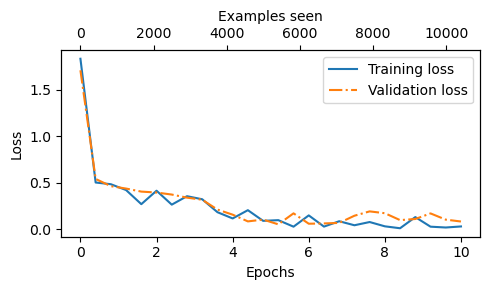

In [42]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_values(epochs_seen, examples_seen, train_values, val_values, label='loss'):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # epoch에 따른 train/validation loss plot
    ax1.plot(epochs_seen, train_values, label=f'Training {label}')
    ax1.plot(epochs_seen, val_values, linestyle='-.', label=f'Validation {label}')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # tokens seen 표기를 위한 2번째 x축 표기
    ax2 = ax1.twiny()   # 같은 y축을 공유하는 2번째 x축 생성
    ax2.plot(examples_seen, train_values, alpha=0)
    ax2.set_xlabel('Examples seen')

    fig.tight_layout()
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))
plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

- 꾸준히 우하향 하고 있음. 즉, 어느정도 잘 learning 하고 있음.
- 또한, train loss와 valid loss가 매우 유사
  - model이 train data에 overfitting하는 경향이 없음을 나타냄.
- 마찬가지로 accuracy를 plot 해보면 다음과 같음

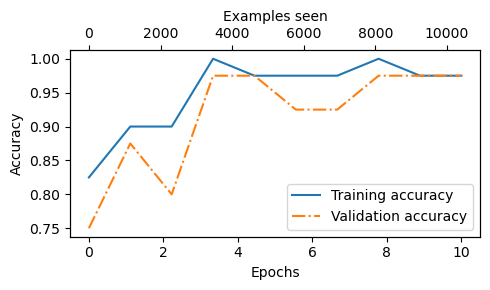

In [43]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

- 완벽한 우상향은 아니긴 하지만, 4~5 epoch 이후 즈음 부터 model이 비교적 높은 train/val accuracy를 달성하는 것을 확인할 수 있음.
- 현재 함수에서 `eval_iter=5`로 지정했기 때문에, train set과 valid set의 성능만을 평가했음.
- 따라서, 다음과 같이 전체 dataset에 대한 train/valid/test accuracy 성능을 계산할 수 있음.

In [44]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 99.42%
Validation accuracy: 97.99%
Test accuracy: 96.67%


- train/val은 충분히 높은데, test 성능이 조금 낮음.
- 이는 model이 train data와 일부 hyperparameter(e.g. learning rate) 조정에 사용된 valid data에 대해 아주 미미한 수준의 overfitting을 보인다는 것을 짐작할 수 있음.
- 이는 정상적인 현상이고, model의 `drop_rate`나 optimizer의 `weight_decay`를 높임으로써 이 차이를 더욱 줄일 수 있음.

## Using LLM as a spam classifier

- 다 완성했으니 finetuned GPT를 이용해보자.
- `classify_review` 함수는 이전에 구현했던 `SpamDataset`과 유사한 data preprocessing step을 수행하고, model에서 예측된 int class label과 해당 class name을 return 함. 

In [45]:
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()

    # model 입력을 위한 준비
    input_ids = tokenizer.encode(text)
    supported_context_length = model.position_embedding.weight.shape[0]

    # sequence가 너무 길면 truncate
    input_ids = input_ids[:min(max_length, supported_context_length)]
    assert max_length is not None, (
        "max_length must be specified. If you want to use the full model context, "
        "pass max_length=model.pos_emb.weight.shape[0]."
    )
    assert max_length <= supported_context_length, (
        f"max_length ({max_length}) exceeds model's supported context length ({supported_context_length})."
    )

    # longest sequence에 맞춰서 sequence를 padding
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0)  # batch dimension 추가

    # Inference
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]  # 마지막 output token의 logit
    predicted_label = torch.argmax(logits, dim=-1).item()

    # 분류된 결과를 return
    return "spam" if predicted_label == 1 else "not spam"

In [46]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

spam


In [47]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

not spam


- 재사용성을 위해 저장하고, 제대로 load 되는지 확인해보자

In [ ]:
torch.save(model.state_dict(), 'review_classifier.pth') # 522 MB

In [49]:
model_state_dict = torch.load("review_classifier.pth", map_location=device, weights_only=True)
model.load_state_dict(model_state_dict)

<All keys matched successfully>